# Day 3 - Observation Kernel ?????

agent ??? hidden state??????????????????????

?? notebook ????????????????????????????????????

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(3)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day03


## ????

????????????????????????????????????????????????????????????????

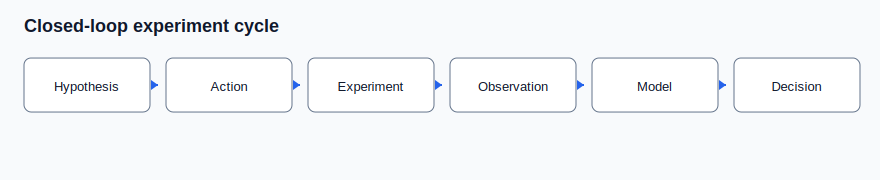

In [2]:
tu.display_tutorial_header(
    day=3,
    title='Observation Kernel ?????',
    subtitle='agent ??? hidden state??????????????????????',
    focus=[
        'partial observability',
        'HPLC / GC / UV-vis / final assay',
        'observed mask',
        'measurement cost',
    ],
    deliverables=[
        '?? instrument ???',
        '?? raw signal ??',
        '????????',
    ],
    project_link='????????????????????????????',
)
tu.display_course_map(3)
display(tu.workflow_svg())


In [3]:
tu.display_api_card()

In [4]:
tu.display_score_terms()

In [5]:
tu.display_student_checkpoint(
    3,
    [
        "one trajectory table or JSONL artifact",
        "one figure generated from your own run",
        "one chemical hypothesis",
        "one proposed next experiment",
        "one note on how GPT or another assistant was used",
    ],
)

,yield,selectivity,conversion,byproduct_signal,degradation_warning,purity,impurity_signal,phase_ratio,recovery,product_in_organic,product_in_aqueous,solvent_loss,process_mass_balance_error
hplc,1.0,1.0,0.0,1.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
gc,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uvvis,1.0,0.0,1.0,0.0,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
final_assay,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


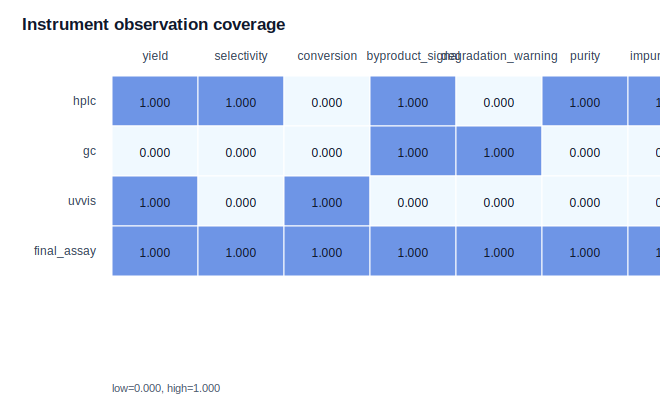

In [6]:
import gymnasium as gym

env = gym.make("ChemWorld", budget=8, seed=3)
env.reset(seed=3)
instruments = env.unwrapped.task_info()["instruments"]
env.close()

fields = [
    "yield",
    "selectivity",
    "conversion",
    "byproduct_signal",
    "degradation_warning",
]
coverage = pd.DataFrame(index=instruments.keys(), columns=fields, data=0.0)
for instrument_id, payload in instruments.items():
    for key in payload["observable_keys"]:
        coverage.loc[instrument_id, key] = 1.0

display(coverage)
display(tu.heatmap_svg(coverage, title="Instrument observation coverage"))

In [7]:
events = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 2},
    {"operation": "add_reagent", "amount_mol": 0.010},
    {
        "operation": "add_catalyst",
        "catalyst_amount_mol": 0.00025,
        "catalyst": 1,
    },
    {
        "operation": "heat",
        "target_temperature_K": 372.0,
        "duration_s": 600.0,
        "stirring_speed_rpm": 720.0,
    },
    {"operation": "measure", "instrument": "uvvis"},
    {"operation": "measure", "instrument": "hplc"},
    {"operation": "measure", "instrument": "gc"},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]
obs_run = tu.run_events(events, seed=21)
obs_run[
    [
        "step",
        "operation",
        "instrument",
        "reward",
        "leaderboard_score",
        "yield",
        "conversion",
        "byproduct",
        "degradation",
        "observed_keys",
    ]
]

,step,operation,instrument,reward,leaderboard_score,yield,conversion,byproduct,degradation,observed_keys
0,1,add_solvent,None,0.0000,NaN,NaN,NaN,NaN,NaN,"cost, safety_risk, score"
1,2,add_reagent,None,0.0000,NaN,NaN,NaN,NaN,NaN,"cost, safety_risk, score"
2,3,add_catalyst,None,0.0000,NaN,NaN,NaN,NaN,NaN,"cost, safety_risk, score"
3,4,heat,None,0.0000,NaN,NaN,NaN,NaN,NaN,"cost, safety_risk, score"
4,5,measure,uvvis,0.4519,NaN,0.8467,1.0000,NaN,NaN,"yield, conversion, phase_ratio, cost, safety_r..."
5,6,measure,hplc,0.5468,NaN,0.8453,NaN,0.0958,NaN,"yield, selectivity, byproduct_signal, purity, ..."
6,7,measure,gc,0.0000,NaN,NaN,NaN,0.1009,0.0675,"byproduct_signal, degradation_warning, virtual..."
7,8,terminate,None,0.0000,NaN,NaN,NaN,0.1009,0.0675,"byproduct_signal, degradation_warning, virtual..."
8,9,measure,final_assay,0.5957,0.5957,0.8161,0.9792,0.0913,0.0644,"yield, selectivity, conversion, byproduct_sign..."


In [8]:
signal_rows = []
for _, row in obs_run[obs_run["instrument"].notna()].iterrows():
    payload = tu.raw_signal_payload(row)
    signal_rows.append(
        {
            "instrument": payload["instrument"],
            "raw_signal": payload["raw_signal"],
            "processed_estimate": payload["processed_estimate"],
            "uncertainty": payload["uncertainty"],
        }
    )
display(pd.DataFrame(signal_rows))
tu.show_json_panel("Example raw signal packet", signal_rows[0])

,instrument,raw_signal,processed_estimate,uncertainty
0,uvvis,"{'kind': 'uvvis_spectrum', 'wavelength_nm': [3...","{'yield': 0.8467372479348476, 'conversion': 1....","{'yield_std': 0.045, 'conversion_std': 0.035, ..."
1,hplc,"{'kind': 'hplc_chromatogram', 'peaks': [{'rete...","{'yield': 0.8452852795028698, 'selectivity': 0...","{'yield_std': 0.012, 'selectivity_std': 0.018,..."
2,gc,"{'kind': 'gc_chromatogram', 'peaks': [{'retent...","{'byproduct_signal': 0.10085793907517246, 'deg...","{'byproduct_signal_std': 0.018, 'degradation_w..."
3,final_assay,"{'kind': 'final_assay_packet', 'quality': 'hig...","{'yield': 0.8160706136432093, 'selectivity': 0...","{'yield_std': 0.006, 'selectivity_std': 0.01, ..."


step,1,2,3,4,5,6,7,8,9
field,,,,,,,,,
byproduct_signal,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
conversion,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
selectivity,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
yield,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


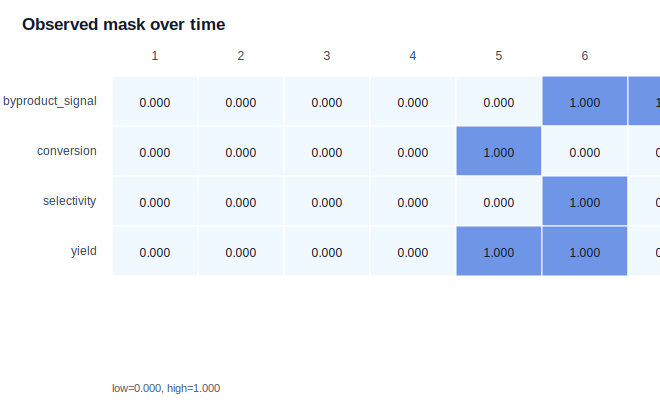

In [9]:
mask_rows = []
for _, row in obs_run.iterrows():
    mask = row["observed_mask"]
    for key in ["yield", "selectivity", "conversion", "byproduct_signal"]:
        mask_rows.append(
            {
                "step": int(row["step"]),
                "instrument": row["instrument"],
                "field": key,
                "observed": bool(mask.get(key, False)),
            }
        )
mask_df = pd.DataFrame(mask_rows)
mask_pivot = mask_df.pivot_table(
    index="field",
    columns="step",
    values="observed",
    aggfunc="max",
).astype(float)
display(mask_pivot)
display(tu.heatmap_svg(mask_pivot, title="Observed mask over time"))

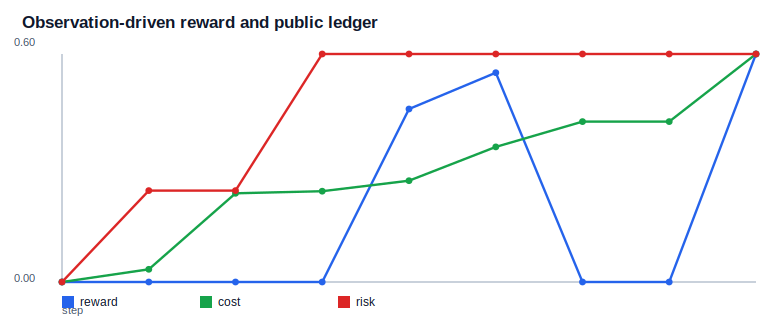

In [10]:
display(
    tu.line_svg(
        obs_run,
        x="step",
        ys=["reward", "cost", "risk"],
        title="Observation-driven reward and public ledger",
    )
)

## 当天练习

假设每次测量都消耗预算。你会先用 UV-vis 便宜地扫趋势，还是直接做 HPLC？
写出你的策略，并说明你愿意牺牲哪些观测字段。


## Exit Ticket

???????????????????????????

In [11]:
tu.display_reflection_box(["????????????????????", "????????? GPT ? BO?"])